# CBGT Stage 1 Feature 1 bin-count analysis

This notebook tests how many pre-decision firing rate bins are needed to separate left- and right-action channels in **Stage 1**. It compares total feature dimensions **2, 4, 6, 8, 10, and 12**, with six from left-choice trials and six from right-choice trials:

- 2D: [L-6 | R-6]
- 4D: [L-6, L-5 | R-6, R-5]
- ...
- 12D: [L-6, ..., L-1 | R-6, ..., R-1], the current analysis

For every dimension, each population profile is z-scored across its selected bins and clustered globally into two groups using Euclidean Ward agglomerative clustering. **Stage 2 is not run in this notebook.**

Run `01_cbgt_reference_clustering.ipynb` first. This notebook reads the derived 12D feature table and does not repeat raw-data preprocessing.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))

import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import linear_sum_assignment
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score, confusion_matrix

from spn_figures.config import DERIVED, FIGURES

CBGT_DERIVED = DERIVED / "cbgt"
FEATURE_PATH = CBGT_DERIVED / "spn_features.csv.gz"
OUTPUT_STEM = FIGURES / "supporting" / "cbgt_feature1_bin_count_stage1_ari"
OUTPUT_STEM.parent.mkdir(parents=True, exist_ok=True)

if not FEATURE_PATH.exists():
    raise FileNotFoundError(
        f"Missing {FEATURE_PATH}. Run 01_cbgt_reference_clustering.ipynb first."
    )

features = pd.read_csv(FEATURE_PATH)
required_columns = {
    "unit_key", "network_id", "true_name",
    *[f"feature_{i:02d}" for i in range(12)],
}

print(
    f"Loaded {len(features):,} simulated SPN populations from "
    f"{features['network_id'].nunique()} networks."
)

Loaded 1,200 simulated SPN populations from 300 networks.


## Feature subsets

The existing table stores the six left-choice means first (`feature_00` to `feature_05`) and the six right-choice means second (`feature_06` to `feature_11`). Each test keeps the requested prefix beginning at bin -6 on both sides.

In [3]:
TOTAL_DIMENSIONS = (2, 4, 6, 8, 10, 12)
BINS_PER_CHOICE_AVAILABLE = 6

def selected_feature_columns(total_dimensions):
    if total_dimensions not in TOTAL_DIMENSIONS:
        raise ValueError(f"total_dimensions must be one of {TOTAL_DIMENSIONS}.")
    bins_per_choice = total_dimensions // 2
    left = [f"feature_{i:02d}" for i in range(bins_per_choice)]
    right = [
        f"feature_{BINS_PER_CHOICE_AVAILABLE + i:02d}"
        for i in range(bins_per_choice)
    ]
    return left + right

feature_design = pd.DataFrame(
    {
        "total_dimensions": TOTAL_DIMENSIONS,
        "bins_per_choice": [d // 2 for d in TOTAL_DIMENSIONS],
        "included_bins": [
            ", ".join(
                [f"L{b}" for b in range(-6, -6 + d // 2)]
                + [f"R{b}" for b in range(-6, -6 + d // 2)]
            )
            for d in TOTAL_DIMENSIONS
        ],
        "source_columns": [
            ", ".join(selected_feature_columns(d)) for d in TOTAL_DIMENSIONS
        ],
    }
)
feature_design

,total_dimensions,bins_per_choice,included_bins,source_columns
0,2,1,"L-6, R-6","feature_00, feature_06"
1,4,2,"L-6, L-5, R-6, R-5","feature_00, feature_01, feature_06, feature_07"
2,6,3,"L-6, L-5, L-4, R-6, R-5, R-4","feature_00, feature_01, feature_02, feature_06..."
3,8,4,"L-6, L-5, L-4, L-3, R-6, R-5, R-4, R-3","feature_00, feature_01, feature_02, feature_03..."
4,10,5,"L-6, L-5, L-4, L-3, L-2, R-6, R-5, R-4, R-3, R-2","feature_00, feature_01, feature_02, feature_03..."
5,12,6,"L-6, L-5, L-4, L-3, L-2, L-1, R-6, R-5, R-4, R...","feature_00, feature_01, feature_02, feature_03..."


## Stage 1 validation function

The full 12D profile is normalized first, and each forward subset is selected from that same normalized profile. The 12D case is therefore identical to the original Stage 1 procedure.

In [4]:
FULL_FEATURE_COLUMNS = [f"feature_{i:02d}" for i in range(12)]


def zscore_rows(x):
    x = np.asarray(x, dtype=float)
    return (x - x.mean(axis=1, keepdims=True)) / (x.std(axis=1, keepdims=True) + 1e-9)


def select_from_full_zscore(feature_table, feature_cols):
    full_x_z = zscore_rows(feature_table[FULL_FEATURE_COLUMNS].to_numpy(float))
    selected_indices = [FULL_FEATURE_COLUMNS.index(col) for col in feature_cols]
    return full_x_z[:, selected_indices]


def align_cluster_ids(true_labels, raw_labels):
    # Cluster IDs are arbitrary; this permutation does not change the partition or ARI.
    matrix = confusion_matrix(true_labels, raw_labels)
    rows, cols = linear_sum_assignment(matrix.max() - matrix)
    mapping = {int(cluster): int(label) for label, cluster in zip(rows, cols)}
    return np.array([mapping[int(label)] for label in raw_labels], dtype=int)


def stage1_channel_validation(feature_table, total_dimensions):
    feature_cols = selected_feature_columns(total_dimensions)
    x_z = select_from_full_zscore(feature_table, feature_cols)
    true_names = feature_table["true_name"].to_numpy(dtype=str)
    true_channel = np.where(np.char.endswith(true_names, "_left"), 0, 1)

    raw_labels = AgglomerativeClustering(
        n_clusters=2,
        linkage="ward",
        metric="euclidean",
    ).fit_predict(x_z)
    labels = align_cluster_ids(true_channel, raw_labels)

    return {
        "feature_columns": feature_cols,
        "labels": labels,
        "ari": adjusted_rand_score(true_channel, labels),
        "accuracy": float(np.mean(true_channel == labels)),
        "confusion": confusion_matrix(
            true_channel, labels, labels=[0, 1], normalize="true"
        ),
    }

## Confirm the original 12D result

The 12D case should reproduce the reported Stage 1 ARI of 0.983. 

In [5]:
original_12d = stage1_channel_validation(features, 12)
if round(original_12d["ari"], 3) != 0.983:
    raise AssertionError(
        f"Expected the 12D Stage 1 ARI to round to 0.983, "
        f"but obtained {original_12d['ari']:.6f}."
    )
print(f"PASS: 12D Stage 1 ARI = {original_12d['ari']:.6f} (reported as 0.983).")

PASS: 12D Stage 1 ARI = 0.983389 (reported as 0.983).


## Run the 2D to 12D Stage 1 sweep

In [6]:
runs = {}
summary_rows = []
assignment_tables = []

for total_dimensions in TOTAL_DIMENSIONS:
    result = stage1_channel_validation(features, total_dimensions)
    runs[total_dimensions] = result
    summary_rows.append(
        {
            "total_dimensions": total_dimensions,
            "bins_per_choice": total_dimensions // 2,
            "included_bins": feature_design.loc[
                feature_design["total_dimensions"] == total_dimensions,
                "included_bins",
            ].iloc[0],
            "stage1_ari": result["ari"],
            "stage1_accuracy": result["accuracy"],
            "n_incorrect": int(round(len(features) * (1.0 - result["accuracy"]))),
        }
    )
    assignment_tables.append(
        pd.DataFrame(
            {
                "total_dimensions": total_dimensions,
                "bins_per_choice": total_dimensions // 2,
                "unit_key": features["unit_key"],
                "network_id": features["network_id"],
                "true_name": features["true_name"],
                "stage1_channel_label": result["labels"],
            }
        )
    )

results = pd.DataFrame(summary_rows).sort_values("total_dimensions").reset_index(drop=True)
assignments = pd.concat(assignment_tables, ignore_index=True)

reference_12d_ari = float(
    results.loc[results["total_dimensions"] == 12, "stage1_ari"].iloc[0]
)
results["ari_fraction_of_12d"] = results["stage1_ari"] / reference_12d_ari
results["ari_gain_from_previous"] = results["stage1_ari"].diff()

results.to_csv(
    CBGT_DERIVED / "feature1_bin_count_stage1_validation_full12d_zscore.csv", index=False
)
assignments.to_csv(
    CBGT_DERIVED / "feature1_bin_count_stage1_assignments_full12d_zscore.csv.gz", index=False
)

results

,total_dimensions,bins_per_choice,included_bins,stage1_ari,stage1_accuracy,n_incorrect,ari_fraction_of_12d,ari_gain_from_previous
0,2,1,"L-6, R-6",-0.000740,0.501667,598,-0.000752,NaN
1,4,2,"L-6, L-5, R-6, R-5",0.010583,0.552500,537,0.010762,0.011323
2,6,3,"L-6, L-5, L-4, R-6, R-5, R-4",0.257794,0.754167,295,0.262149,0.247211
3,8,4,"L-6, L-5, L-4, L-3, R-6, R-5, R-4, R-3",0.480293,0.846667,184,0.488406,0.222498
4,10,5,"L-6, L-5, L-4, L-3, L-2, R-6, R-5, R-4, R-3, R-2",0.337871,0.790833,251,0.343579,-0.142421
5,12,6,"L-6, L-5, L-4, L-3, L-2, L-1, R-6, R-5, R-4, R...",0.983389,0.995833,5,1.000000,0.645517


## Stage 1 ARI versus available pre-decision information

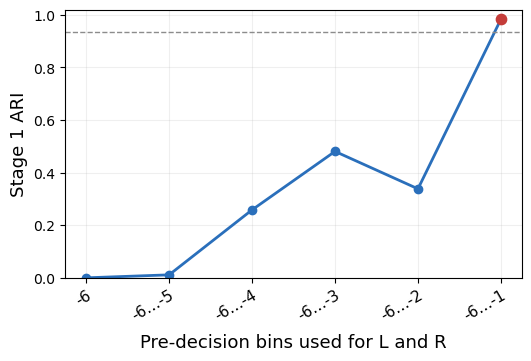

In [8]:
fig, ax = plt.subplots(figsize=(5.2, 3.5), constrained_layout=True)
ax.plot(
    results["total_dimensions"],
    results["stage1_ari"],
    color="#2A6FBB",
    marker="o",
    linewidth=2,
    markersize=6,
)
ax.scatter(
    [12], [reference_12d_ari], color="#C43C39", s=55, zorder=3, label="Current 12D feature"
)
ax.axhline(0.95 * reference_12d_ari, color="0.55", linestyle="--", linewidth=1, label="95% of 12D ARI")
forward_labels = [
    "-6",
    "-6…-5",
    "-6…-4",
    "-6…-3",
    "-6…-2",
    "-6…-1",
]

ax.set_xticks(TOTAL_DIMENSIONS)
ax.set_xticklabels(
    forward_labels,
    rotation=30,
    ha="right",
    rotation_mode="anchor",
    fontsize=11,
)
ax.set_xlabel(
    "Pre-decision bins used for L and R",
    fontsize=13,
    labelpad=7,
)
ax.set_ylabel("Stage 1 ARI", fontsize=13)
ax.set_ylim(0, 1.02)
ax.grid(alpha=0.2)
#fig.savefig(OUTPUT_STEM.parent / "FigSX_cbgt_feature1_bin_count_stage1_ari.png", dpi=300, bbox_inches="tight")
plt.show()